# An Introduction to Shapley Values in Biology - Drosophila Development

### CGSI Tutorial 2026
**Kris Sankaran**
2026-07-20

### Drosophila Development Case Study
This notebook contains the R code examples from the original document, specifically the Drosophila development case study.

In [1]:
# Setup - Install required packages
#install.packages("pak")
#pak::pkg_install(c('tidyverse', 'reticulate', 'mlr3', 'mlr3learners', 'mlr3tuning', 'patchwork', 'shapviz'))

library(tidyverse)
library(reticulate)
theme_set(theme_classic() + theme(panel.border = element_rect(fill = NA, linewidth = .5)))
set.seed(2026)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


### Drosophila Development Analysis
#### Problem Formulation
1. Enhancers are DNA sequences that coordinate downstream gene expression. Their activity depends on genome state, like transcription factor binding and chromatin state.

2. Understanding enhancers means understanding how genotype becomes phenotype, a fundamental problem in biology.

3. Basu et al. (2018) asked: given the genomic state of a fruit fly embryo at a fixed developmental stage, can we predict whether a given enhancer is active?

In [2]:
# Load required R packages
source('https://github.com/krisrs1128/stat479_notes/raw/refs/heads/master/activities/05-helpers.R')
library(mlr3)
library(mlr3learners)
library(mlr3tuning)
library(patchwork)
library(shapviz)
library(tidyverse)
theme_set(theme_classic())
set.seed(20251227)
options(mlr3.store_backends = TRUE)

Loading required package: paradox



In [15]:
# Download and load the enhancer data
f <- tempfile()
download.file('https://zenodo.org/records/18371236/files/enhancer.Rdata?download=1', f)
load(f)

enhancer <- bind_cols(y = as.factor(Y), X)
head(enhancer)

y,H3_c12,H3_c14a,H3_c14c,H3_c8,H3K18ac_c12,H3K18ac_c14a,H3K18ac_c14c,H3K18ac_c8,H3K27ac_c12,⋯,run2,shn2,shn3,slp1,sna1,sna2,tll1,twi1,twi2,z2
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0,6,10,10,8,5,7,8,9,12,⋯,0,0,0,0,0,0,0,0,0,0.00000
0,6,7,6,5,19,10,11,0,4,⋯,0,0,0,0,0,0,0,0,0,0.00000
0,14,9,14,13,11,9,19,10,1,⋯,0,0,0,0,0,0,0,0,0,1.20130
0,13,17,13,13,19,14,25,10,29,⋯,0,0,0,0,0,0,0,0,0,0.00000
1,6,6,6,10,13,23,28,10,8,⋯,0,0,0,0,0,0,0,0,0,1.21019
1,10,9,9,11,12,23,28,7,29,⋯,0,0,0,0,0,0,0,0,0,1.21019


In [16]:
# Model Training Setup
task <- as_task_classif(enhancer, target = 'y', id = 'enhancer', positive = '1')
learner <- lrn('classif.xgboost', nrounds = to_tune(100, 200), eta = to_tune(1e-3, 0.1), predict_type = 'prob')

instance <- ti(
    task = task,
    learner = learner,
    resampling = rsmp('cv', folds = 3),
    measures = msr('classif.auc'),
    terminator = trm('none')
)

In [18]:
# Hyperparameter tuning
tuner <- tnr('grid_search', resolution = 5, batch_size = 5)
tuner$optimize(instance)

INFO  [21:24:43.313] [bbotk] Starting to optimize 2 parameter(s) with '<OptimizerBatchGridSearch>' and '<TerminatorNone>'
INFO  [21:24:43.323] [bbotk] Evaluating 5 configuration(s)
INFO  [21:24:43.329] [mlr3] Running benchmark with 15 resampling iterations
INFO  [21:24:43.335] [mlr3] Applying learner 'classif.xgboost' on task 'enhancer' (iter 1/3)
INFO  [21:24:43.956] [mlr3] Applying learner 'classif.xgboost' on task 'enhancer' (iter 2/3)
INFO  [21:24:44.654] [mlr3] Applying learner 'classif.xgboost' on task 'enhancer' (iter 3/3)
INFO  [21:24:45.300] [mlr3] Applying learner 'classif.xgboost' on task 'enhancer' (iter 1/3)
INFO  [21:24:45.885] [mlr3] Applying learner 'classif.xgboost' on task 'enhancer' (iter 2/3)
INFO  [21:24:46.655] [mlr3] Applying learner 'classif.xgboost' on task 'enhancer' (iter 3/3)
INFO  [21:24:47.245] [mlr3] Applying learner 'classif.xgboost' on task 'enhancer' (iter 1/3)
INFO  [21:24:47.934] [mlr3] Applying learner 'classif.xgboost' on task 'enhancer' (iter 2/3)

eta,nrounds,learner_param_vals,x_domain,classif.auc
<dbl>,<int>,<list>,<list>,<dbl>
0.02575,100,"1.00000, 0.00000, 0.00000, 1.00000, 0.02575, 100.00000","0.02575, 100.00000",0.8361742


In [19]:
# Fit final model with optimized hyperparameters
learner$param_set$values <- instance$result_learner_param_vals
task <- as_task_classif(enhancer, target = 'y', id = 'enhancer', positive = '1')
learner$train(task)

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


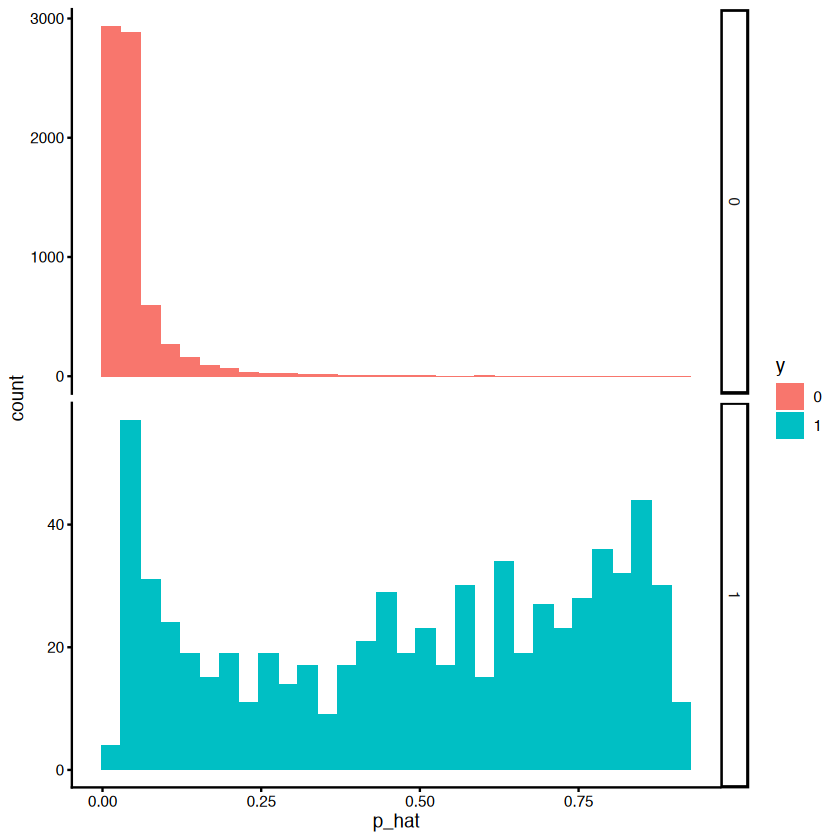

In [20]:
# Model predictions
tibble(p_hat = learner$predict_newdata(enhancer)$prob[, 1], y = enhancer$y) |>
    ggplot() +
    geom_histogram(aes(p_hat, fill = y)) +
    facet_grid(y ~ ., scales = 'free_y')

In [21]:
# SHAP interpretation setup
X_mat <- as.matrix(X)
shp <- shapviz(learner$model, X_pred = X_mat)
shp$S[1:5, 1:8]  # Show first few SHAP values

,H3_c12,H3_c14a,H3_c14c,H3_c8,H3K18ac_c12,H3K18ac_c14a,H3K18ac_c14c,H3K18ac_c8
VT0002,0.068839401,-0.034920834,-0.008018139,-0.07555990,0.0327704698,0.041389603,0.0031723969,0.011215613
VT0003,0.064319402,-0.004164241,0.007724053,-0.03716381,-0.0258688685,0.016818035,0.0003347002,0.008839345
VT0004,0.083743654,-0.037574559,-0.007068704,-0.07883391,0.0002055851,0.041915886,-0.0014176624,0.001084273
VT0005,0.055233277,0.009904596,-0.002665190,-0.03974437,-0.0256465226,-0.001247977,0.0006725105,0.016408261
VT0006,-0.004646949,-0.001682470,-0.053047363,-0.02233944,-0.0076694093,-0.009059546,-0.0014770469,0.007148674


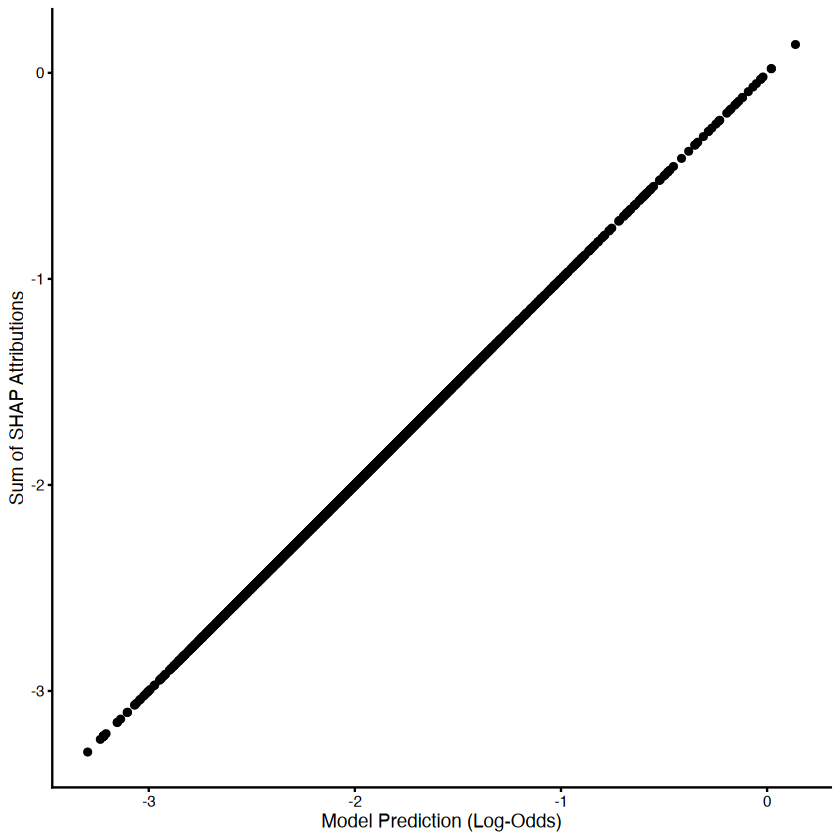

In [22]:
# Check efficiency axiom
y_hat <- predict(learner$model, X_mat, outputmargin = TRUE)

tibble(y_hat = y_hat, sum_phi = rowSums(shp$S) + shp$baseline) |>
    ggplot() +
    geom_point(aes(y_hat, sum_phi)) +
    labs(
        x = 'Model Prediction (Log-Odds)',
        y = 'Sum of SHAP Attributions'
    )

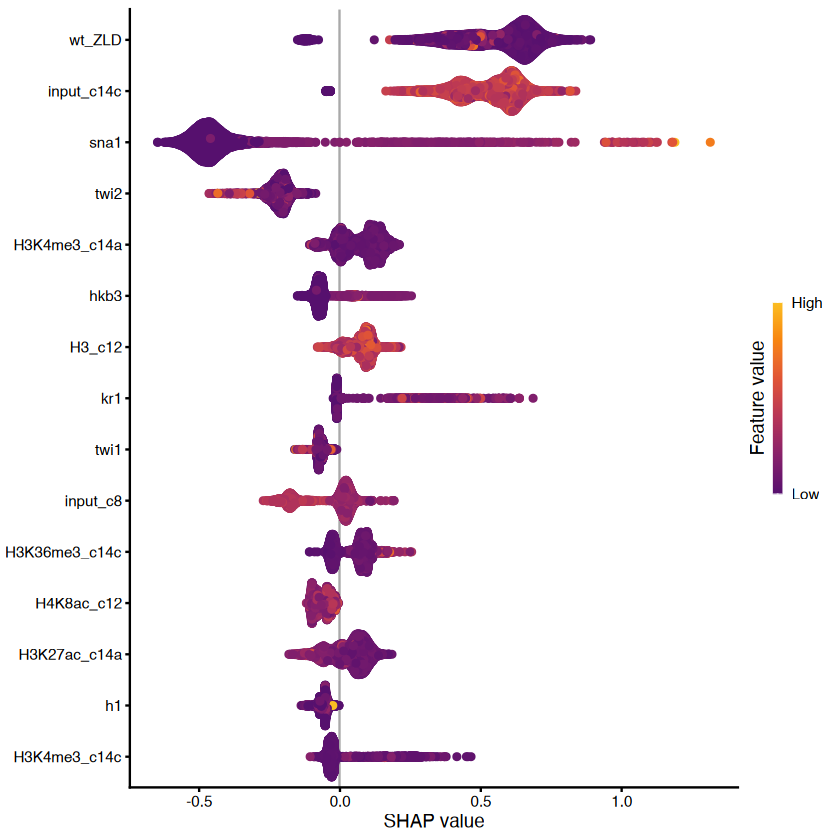

In [23]:
# Variable-level importance plot
sv_importance(shp, kind = 'bee')

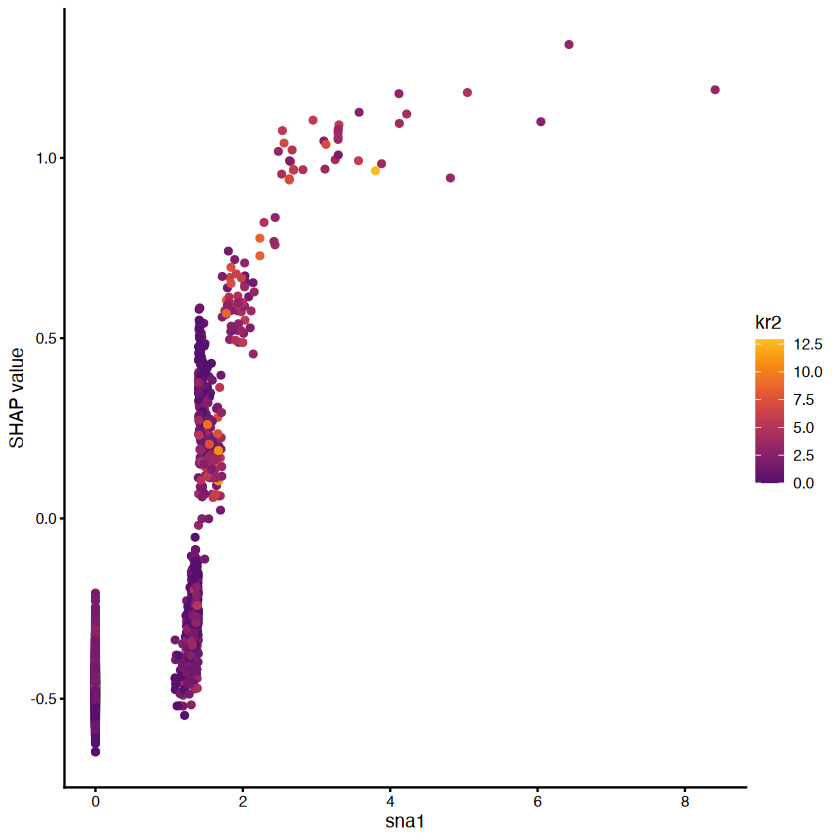

In [24]:
# Dependence plot for sna1 feature
sv_dependence(shp, 'sna1')

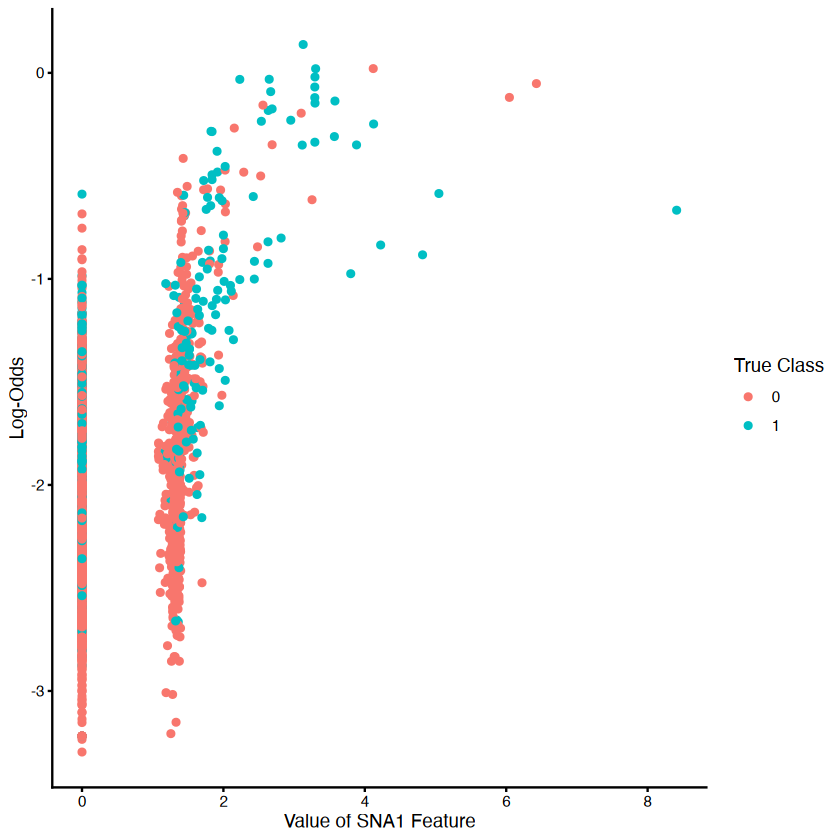

In [25]:
# Detailed analysis of sna1 feature
tibble(p_hat = predict(learner$model, X_mat, outputmargin = TRUE),
       y = enhancer$y,
       x = enhancer$sna1) |>
    ggplot() +
    geom_point(aes(x, p_hat, col = y)) +
    labs(x = 'Value of SNA1 Feature', y = 'Log-Odds', col = 'True Class')

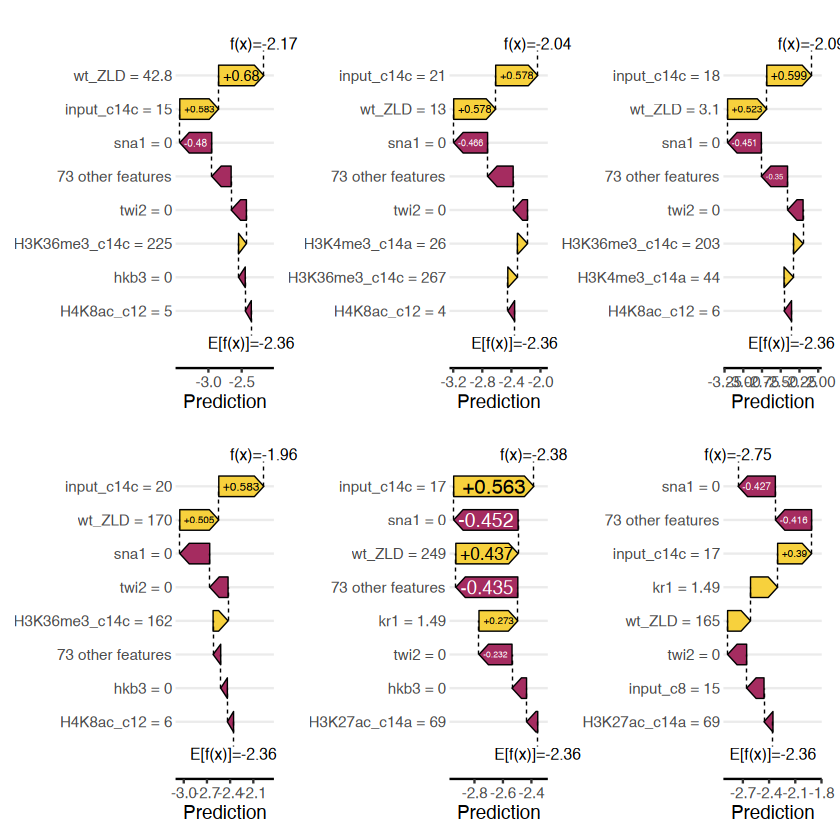

In [26]:
# Sample-level waterfall plots
map(seq_len(6), ~sv_waterfall(shp, max_display = 8, row = .x)) |>
    reduce(`+`)

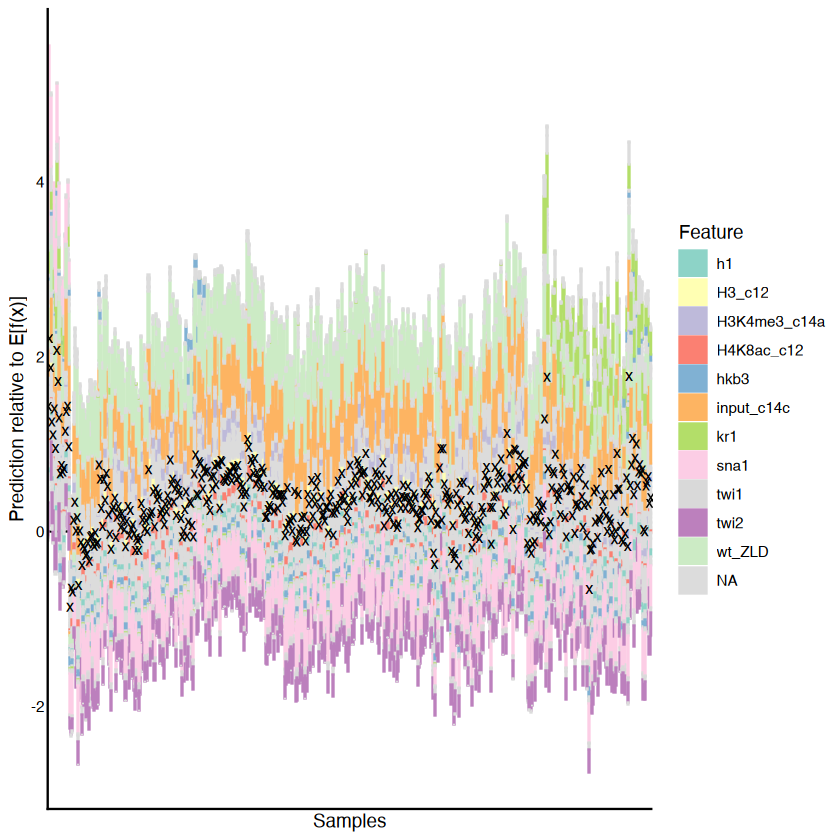

In [27]:
# Custom stacked bar plot for SHAP values
var_order <- order(abs(colSums(shp$S)), decreasing = TRUE)
important_vars <- colnames(shp$S)[var_order] |>
    head(11)

ix <- sample(1:nrow(enhancer), 500)
shap_bars <- shap_to_long(shp$S[ix, ], y_hat[ix], shp$baseline, important_vars) |>
    add_waterfall_offsets()

ggplot(shap_bars) +
    geom_hline(yintercept = 0) +
    geom_rect(aes(xmin = xpos - 0.45, xmax = xpos + 0.45, ymin = ymin, ymax = ymax, fill = name, col = name)) +
    geom_point(
        data = distinct(shap_bars, xpos, pred),
        aes(xpos, pred),
        size = 3,
        shape = 'x'
    ) +
    labs(y = 'Prediction relative to E[f(x)]', x = 'Samples', fill = 'Feature', col = 'Feature') +
    scale_x_continuous(expand = c(0, 0)) +
    scale_fill_brewer(palette = 'Set3', na.value = '#dcdcdc') +
    scale_color_brewer(palette = 'Set3', na.value = '#dcdcdc') +
    theme(
        axis.ticks = element_blank(),
        axis.text.x = element_blank(),
    )

### References
1. Basu, S., et al. (2018). Predicting enhancer activity from DNA sequence using deep convolutional neural networks. Nature communications, 9(1), 1-12.
2. Lundberg, S. M., & Lee, S. I. (2017). A unified approach to interpreting model predictions. Advances in neural information processing systems, 30.
3. Janzing, D., et al. (2020). Feature relevance quantification in explainable AI: A causal problem. Journal of Machine Learning Research, 21(126), 1-42.